# Pandas Case Study: TechMart E-Commerce Analysis

## Scenario

You have been hired as a Data Analyst at **TechMart**, an online electronics retailer. The company wants to understand their sales performance, customer behavior, and identify opportunities for growth.

You have been given three datasets:
1. **Orders** - Transaction records
2. **Customers** - Customer information
3. **Products** - Product catalog

Your task is to clean, merge, and analyze this data to provide actionable insights.

---

## Skills Tested

| Module | Concepts |
|--------|----------|
| **07a** | Loading data, viewing data, basic info, value_counts |
| **07b** | Filtering, sorting, missing values, duplicates, groupby, merging |
| **07c** | Apply, datetime operations, string operations, new columns, pivot tables, visualization |

---

## Instructions

1. Complete each task in the provided code cells
2. Run your code to verify it works
3. Answer the analysis questions based on your results
4. Expected outputs are provided to help you verify your answers

**Estimated Time:** 2-3 hours

---

# Part 0: Import library and load dataset


In [ ]:
import pandas as pd
orders = pd.read_csv('./pandas_data/orders.csv')
customers = pd.read_csv('./pandas_data/customers.csv')
products = pd.read_csv('./pandas_data/products.csv')

---

# Part 1: Data Exploration (07a Concepts)

Before any analysis, you need to understand your data.

## Task 1.1: Explore the Orders Data

1. Display the first 10 rows of the orders DataFrame
2. Display the last 5 rows
3. Display 5 random rows

In [2]:
# Your code here
print(orders.head(10))
print(orders.tail())
print(orders.sample(n=5))

   order_id  customer_id  product_id  quantity  order_date      status
0      1001            2         113       1.0  2024-04-12     Shipped
1      1002          128         102       1.0  2024-12-14   Completed
2      1003           84         119       1.0  2024-09-27   Completed
3      1004          140         119       1.0  2024-04-16   Completed
4      1005          124         104       1.0  2024-03-12  Processing
5      1006           33         104       1.0  2024-07-07   Completed
6      1007          101         111       1.0  2024-01-21   Completed
7      1008           12         105       3.0  2024-04-12   Completed
8      1009           67         120       2.0  2024-05-01     Shipped
9      1010           65         111       2.0  2024-08-02   Completed
     order_id  customer_id  product_id  quantity  order_date      status
505      1455           89         117       3.0  2024-08-24  Processing
506      1071          123         125       3.0  2024-02-13     Shipped


## Task 1.2: Basic Information

1. What are the dimensions (shape) of each DataFrame?
2. What are the data types of columns in the orders DataFrame?
3. Use `.info()` on the orders DataFrame - how many non-null values are in each column?

In [3]:
# Your code here
print(orders.shape,products.shape,customers.shape)
print('*'*50)
print(orders.dtypes)
print('*'*50)
print(orders.info())

(510, 6) (25, 5) (150, 8)
**************************************************
order_id         int64
customer_id      int64
product_id       int64
quantity       float64
order_date      object
status          object
dtype: object
**************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   order_id     510 non-null    int64  
 1   customer_id  510 non-null    int64  
 2   product_id   510 non-null    int64  
 3   quantity     502 non-null    float64
 4   order_date   510 non-null    object 
 5   status       503 non-null    object 
dtypes: float64(1), int64(3), object(2)
memory usage: 24.0+ KB
None


## Task 1.3: Statistical Summary

1. Use `.describe()` on the products DataFrame
2. What is the average product price? What is the most expensive product price?

In [4]:
# Your code here
prod_desc = products.describe()
print(f"Average price:{prod_desc.loc['mean','price']}")
print(f"Maximum price:{prod_desc.loc['max','price']}")

Average price:299.48
Maximum price:1299.0


**Expected Answer:** Average price is $268.44, Maximum price is $1,299

## Task 1.4: Value Counts

1. How many orders are in each status category?
2. How many products are in each category?
3. What is the distribution of customer membership types?

In [5]:
# Your code here
orders.groupby('status').count()

,order_id,customer_id,product_id,quantity,order_date
status,,,,,
Cancelled,68,68,68,67,68
Completed,289,289,289,284,289
Processing,76,76,76,74,76
Shipped,70,70,70,70,70


In [6]:
products.groupby('category').count()

,product_id,product_name,price,cost
category,,,,
Accessories,12,12,12,12
Audio,4,4,4,4
Desktops,2,2,2,2
Laptops,2,2,2,2
Monitors,3,3,3,3
Tablets,2,2,2,2


In [7]:
customers.groupby('membership').count()

,customer_id,first_name,last_name,email,city,join_date,region
membership,,,,,,,
Basic,74,74,74,74,74,74,74
Gold,32,32,32,32,32,32,32
Premium,39,39,39,39,39,39,39


---

# Part 2: Data Cleaning (07b Concepts)

Real data is messy. Let's clean it up!

## Task 2.1: Handle Missing Values

1. How many missing values are in each column of the orders DataFrame?
2. For the `quantity` column: fill missing values with the median quantity
3. For the `status` column: fill missing values with 'Unknown'
4. Verify there are no more missing values in orders

In [8]:
# Your code here
orders.isnull().sum()

order_id       0
customer_id    0
product_id     0
quantity       8
order_date     0
status         7
dtype: int64

In [9]:
orders['quantity'] = orders['quantity'].fillna(orders['quantity'].median())

In [10]:
orders['status'] = orders['status'].fillna('Unknown')

In [11]:
orders.isnull().sum()

order_id       0
customer_id    0
product_id     0
quantity       0
order_date     0
status         0
dtype: int64

In [12]:
orders

,order_id,customer_id,product_id,quantity,order_date,status
0,1001,2,113,1.0,2024-04-12,Shipped
1,1002,128,102,1.0,2024-12-14,Completed
2,1003,84,119,1.0,2024-09-27,Completed
3,1004,140,119,1.0,2024-04-16,Completed
4,1005,124,104,1.0,2024-03-12,Processing
...,...,...,...,...,...,...
505,1455,89,117,3.0,2024-08-24,Processing
506,1071,123,125,3.0,2024-02-13,Shipped
507,1229,38,119,3.0,2024-11-20,Completed
508,1352,59,115,3.0,2024-05-07,Completed


## Task 2.2: Handle Duplicates

1. How many duplicate rows are in the orders DataFrame?
2. Remove the duplicate rows (keep the first occurrence)
3. Verify the duplicates were removed - what is the new shape?

In [13]:
# Your code here
orders.duplicated().sum()
orders[orders.duplicated()]

,order_id,customer_id,product_id,quantity,order_date,status
500,1233,30,108,2.0,2024-05-23,Completed
501,1013,44,106,1.0,2024-04-09,Processing
502,1096,109,117,3.0,2024-12-10,Completed
503,1250,69,118,3.0,2024-02-08,Completed
504,1170,30,103,1.0,2024-11-26,Cancelled
505,1455,89,117,3.0,2024-08-24,Processing
506,1071,123,125,3.0,2024-02-13,Shipped
507,1229,38,119,3.0,2024-11-20,Completed
508,1352,59,115,3.0,2024-05-07,Completed
509,1282,12,122,3.0,2024-03-15,Completed


In [14]:
orders = orders.drop_duplicates()
orders.duplicated().sum()

np.int64(0)

In [15]:
orders.shape

(500, 6)

**Expected Answer:** 10 duplicate rows, final shape should be (500, 6)

## Task 2.3: Handle Missing Values in Customers

1. Check for missing values in the customers DataFrame
2. Fill missing membership values with 'Basic' (the most common type)
3. Verify no missing values remain

In [16]:
# Your code here
customers.isnull().sum()

customer_id    0
first_name     0
last_name      0
email          0
city           0
join_date      0
membership     5
region         0
dtype: int64

In [17]:
customers['membership'] = customers['membership'].fillna('Basic')

In [18]:
customers.isnull().sum()

customer_id    0
first_name     0
last_name      0
email          0
city           0
join_date      0
membership     0
region         0
dtype: int64

---

# Part 3: Data Merging (07b Concepts)

Combine the three datasets to enable comprehensive analysis.

## Task 3.1: Merge Orders with Products

1. Merge the `orders` DataFrame with the `products` DataFrame on `product_id`
2. Use an inner join
3. Store the result in a variable called `orders_products`
4. Display the first 5 rows and the shape

In [19]:
# Your code here
orders_products = orders.merge(products, on='product_id', how='inner')
orders_products.head()

,order_id,customer_id,product_id,quantity,order_date,status,product_name,category,price,cost
0,1001,2,113,1.0,2024-04-12,Shipped,Webcam 4K,Accessories,149,70
1,1002,128,102,1.0,2024-12-14,Completed,"Laptop Air 13""",Laptops,999,650
2,1003,84,119,1.0,2024-09-27,Completed,Earbuds Sport,Audio,99,45
3,1004,140,119,1.0,2024-04-16,Completed,Earbuds Sport,Audio,99,45
4,1005,124,104,1.0,2024-03-12,Processing,Desktop Mini,Desktops,599,380


## Task 3.2: Create Complete Dataset

1. Merge `orders_products` with the `customers` DataFrame on `customer_id`
2. Use an inner join
3. Store the result in a variable called `df`
4. Display the columns and shape

In [20]:
# Your code here
df = orders_products.merge(customers, on='customer_id', how='inner')
df.columns

Index(['order_id', 'customer_id', 'product_id', 'quantity', 'order_date',
       'status', 'product_name', 'category', 'price', 'cost', 'first_name',
       'last_name', 'email', 'city', 'join_date', 'membership', 'region'],
      dtype='object')

In [21]:
df.shape

(500, 17)

**Expected Answer:** The merged DataFrame should have 500 rows and 17 columns

---

# Part 4: Feature Engineering (07c Concepts)

Create new columns to enable deeper analysis.

## Task 4.1: Calculate Revenue and Profit

1. Create a column `revenue` = price * quantity
2. Create a column `profit` = (price - cost) * quantity
3. Display the first 5 rows showing order_id, product_name, price, quantity, revenue, profit

In [22]:
# Your code here
df['revenue'] = df['price']*df['quantity']
df

,order_id,customer_id,product_id,quantity,order_date,status,product_name,category,price,cost,first_name,last_name,email,city,join_date,membership,region,revenue
0,1001,2,113,1.0,2024-04-12,Shipped,Webcam 4K,Accessories,149,70,Jennifer,Lopez,customer2@email.com,Dallas,2023-04-26,Premium,South,149.0
1,1002,128,102,1.0,2024-12-14,Completed,"Laptop Air 13""",Laptops,999,650,Jessica,Smith,customer128@email.com,San Antonio,2023-03-05,Basic,South,999.0
2,1003,84,119,1.0,2024-09-27,Completed,Earbuds Sport,Audio,99,45,Robert,Rodriguez,customer84@email.com,Austin,2023-08-23,Premium,South,99.0
3,1004,140,119,1.0,2024-04-16,Completed,Earbuds Sport,Audio,99,45,John,Rodriguez,customer140@email.com,Dallas,2023-09-25,Basic,South,99.0
4,1005,124,104,1.0,2024-03-12,Processing,Desktop Mini,Desktops,599,380,Patricia,Rodriguez,customer124@email.com,Dallas,2023-07-14,Gold,South,599.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,1496,136,119,1.0,2024-11-20,Cancelled,Earbuds Sport,Audio,99,45,James,Miller,customer136@email.com,Dallas,2023-01-23,Premium,South,99.0
496,1497,5,113,3.0,2024-01-04,Completed,Webcam 4K,Accessories,149,70,Mary,Davis,customer5@email.com,Houston,2023-08-20,Basic,South,447.0
497,1498,47,114,2.0,2024-01-16,Shipped,USB Hub,Accessories,29,12,William,Gonzalez,customer47@email.com,Dallas,2023-08-27,Basic,South,58.0
498,1499,68,110,2.0,2024-10-06,Completed,"Monitor 32""",Monitors,449,270,Richard,Lopez,customer68@email.com,Houston,2023-06-22,Gold,South,898.0


In [23]:
df['profit'] = (df['price']-df['cost'])*df['quantity']
df.head()

,order_id,customer_id,product_id,quantity,order_date,status,product_name,category,price,cost,first_name,last_name,email,city,join_date,membership,region,revenue,profit
0,1001,2,113,1.0,2024-04-12,Shipped,Webcam 4K,Accessories,149,70,Jennifer,Lopez,customer2@email.com,Dallas,2023-04-26,Premium,South,149.0,79.0
1,1002,128,102,1.0,2024-12-14,Completed,"Laptop Air 13""",Laptops,999,650,Jessica,Smith,customer128@email.com,San Antonio,2023-03-05,Basic,South,999.0,349.0
2,1003,84,119,1.0,2024-09-27,Completed,Earbuds Sport,Audio,99,45,Robert,Rodriguez,customer84@email.com,Austin,2023-08-23,Premium,South,99.0,54.0
3,1004,140,119,1.0,2024-04-16,Completed,Earbuds Sport,Audio,99,45,John,Rodriguez,customer140@email.com,Dallas,2023-09-25,Basic,South,99.0,54.0
4,1005,124,104,1.0,2024-03-12,Processing,Desktop Mini,Desktops,599,380,Patricia,Rodriguez,customer124@email.com,Dallas,2023-07-14,Gold,South,599.0,219.0


## Task 4.2: DateTime Feature Engineering

Using the `order_date` column, create the following new columns:
1. `order_month` - the month number (1-12)
2. `order_quarter` - the quarter (1-4)
3. `order_day_name` - the day of the week name (Monday, Tuesday, etc.)
4. `is_weekend` - True if Saturday or Sunday, False otherwise

Display the first 10 rows showing order_date and these new columns.

In [24]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_month']= df['order_date'].dt.month
df

,order_id,customer_id,product_id,quantity,order_date,status,product_name,category,price,cost,first_name,last_name,email,city,join_date,membership,region,revenue,profit,order_month
0,1001,2,113,1.0,2024-04-12,Shipped,Webcam 4K,Accessories,149,70,Jennifer,Lopez,customer2@email.com,Dallas,2023-04-26,Premium,South,149.0,79.0,4
1,1002,128,102,1.0,2024-12-14,Completed,"Laptop Air 13""",Laptops,999,650,Jessica,Smith,customer128@email.com,San Antonio,2023-03-05,Basic,South,999.0,349.0,12
2,1003,84,119,1.0,2024-09-27,Completed,Earbuds Sport,Audio,99,45,Robert,Rodriguez,customer84@email.com,Austin,2023-08-23,Premium,South,99.0,54.0,9
3,1004,140,119,1.0,2024-04-16,Completed,Earbuds Sport,Audio,99,45,John,Rodriguez,customer140@email.com,Dallas,2023-09-25,Basic,South,99.0,54.0,4
4,1005,124,104,1.0,2024-03-12,Processing,Desktop Mini,Desktops,599,380,Patricia,Rodriguez,customer124@email.com,Dallas,2023-07-14,Gold,South,599.0,219.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,1496,136,119,1.0,2024-11-20,Cancelled,Earbuds Sport,Audio,99,45,James,Miller,customer136@email.com,Dallas,2023-01-23,Premium,South,99.0,54.0,11
496,1497,5,113,3.0,2024-01-04,Completed,Webcam 4K,Accessories,149,70,Mary,Davis,customer5@email.com,Houston,2023-08-20,Basic,South,447.0,237.0,1
497,1498,47,114,2.0,2024-01-16,Shipped,USB Hub,Accessories,29,12,William,Gonzalez,customer47@email.com,Dallas,2023-08-27,Basic,South,58.0,34.0,1
498,1499,68,110,2.0,2024-10-06,Completed,"Monitor 32""",Monitors,449,270,Richard,Lopez,customer68@email.com,Houston,2023-06-22,Gold,South,898.0,358.0,10


In [25]:
df['order_quarter'] = df['order_date'].dt.quarter
df

,order_id,customer_id,product_id,quantity,order_date,status,product_name,category,price,cost,...,last_name,email,city,join_date,membership,region,revenue,profit,order_month,order_quarter
0,1001,2,113,1.0,2024-04-12,Shipped,Webcam 4K,Accessories,149,70,...,Lopez,customer2@email.com,Dallas,2023-04-26,Premium,South,149.0,79.0,4,2
1,1002,128,102,1.0,2024-12-14,Completed,"Laptop Air 13""",Laptops,999,650,...,Smith,customer128@email.com,San Antonio,2023-03-05,Basic,South,999.0,349.0,12,4
2,1003,84,119,1.0,2024-09-27,Completed,Earbuds Sport,Audio,99,45,...,Rodriguez,customer84@email.com,Austin,2023-08-23,Premium,South,99.0,54.0,9,3
3,1004,140,119,1.0,2024-04-16,Completed,Earbuds Sport,Audio,99,45,...,Rodriguez,customer140@email.com,Dallas,2023-09-25,Basic,South,99.0,54.0,4,2
4,1005,124,104,1.0,2024-03-12,Processing,Desktop Mini,Desktops,599,380,...,Rodriguez,customer124@email.com,Dallas,2023-07-14,Gold,South,599.0,219.0,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,1496,136,119,1.0,2024-11-20,Cancelled,Earbuds Sport,Audio,99,45,...,Miller,customer136@email.com,Dallas,2023-01-23,Premium,South,99.0,54.0,11,4
496,1497,5,113,3.0,2024-01-04,Completed,Webcam 4K,Accessories,149,70,...,Davis,customer5@email.com,Houston,2023-08-20,Basic,South,447.0,237.0,1,1
497,1498,47,114,2.0,2024-01-16,Shipped,USB Hub,Accessories,29,12,...,Gonzalez,customer47@email.com,Dallas,2023-08-27,Basic,South,58.0,34.0,1,1
498,1499,68,110,2.0,2024-10-06,Completed,"Monitor 32""",Monitors,449,270,...,Lopez,customer68@email.com,Houston,2023-06-22,Gold,South,898.0,358.0,10,4


In [26]:
df['order_day_name'] = df['order_date'].dt.day_name()
df

,order_id,customer_id,product_id,quantity,order_date,status,product_name,category,price,cost,...,email,city,join_date,membership,region,revenue,profit,order_month,order_quarter,order_day_name
0,1001,2,113,1.0,2024-04-12,Shipped,Webcam 4K,Accessories,149,70,...,customer2@email.com,Dallas,2023-04-26,Premium,South,149.0,79.0,4,2,Friday
1,1002,128,102,1.0,2024-12-14,Completed,"Laptop Air 13""",Laptops,999,650,...,customer128@email.com,San Antonio,2023-03-05,Basic,South,999.0,349.0,12,4,Saturday
2,1003,84,119,1.0,2024-09-27,Completed,Earbuds Sport,Audio,99,45,...,customer84@email.com,Austin,2023-08-23,Premium,South,99.0,54.0,9,3,Friday
3,1004,140,119,1.0,2024-04-16,Completed,Earbuds Sport,Audio,99,45,...,customer140@email.com,Dallas,2023-09-25,Basic,South,99.0,54.0,4,2,Tuesday
4,1005,124,104,1.0,2024-03-12,Processing,Desktop Mini,Desktops,599,380,...,customer124@email.com,Dallas,2023-07-14,Gold,South,599.0,219.0,3,1,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,1496,136,119,1.0,2024-11-20,Cancelled,Earbuds Sport,Audio,99,45,...,customer136@email.com,Dallas,2023-01-23,Premium,South,99.0,54.0,11,4,Wednesday
496,1497,5,113,3.0,2024-01-04,Completed,Webcam 4K,Accessories,149,70,...,customer5@email.com,Houston,2023-08-20,Basic,South,447.0,237.0,1,1,Thursday
497,1498,47,114,2.0,2024-01-16,Shipped,USB Hub,Accessories,29,12,...,customer47@email.com,Dallas,2023-08-27,Basic,South,58.0,34.0,1,1,Tuesday
498,1499,68,110,2.0,2024-10-06,Completed,"Monitor 32""",Monitors,449,270,...,customer68@email.com,Houston,2023-06-22,Gold,South,898.0,358.0,10,4,Sunday


In [27]:
df['is_weekend'] = (df['order_day_name'] == 'Saturday') | (df['order_day_name'] == 'Sunday')
df

,order_id,customer_id,product_id,quantity,order_date,status,product_name,category,price,cost,...,city,join_date,membership,region,revenue,profit,order_month,order_quarter,order_day_name,is_weekend
0,1001,2,113,1.0,2024-04-12,Shipped,Webcam 4K,Accessories,149,70,...,Dallas,2023-04-26,Premium,South,149.0,79.0,4,2,Friday,False
1,1002,128,102,1.0,2024-12-14,Completed,"Laptop Air 13""",Laptops,999,650,...,San Antonio,2023-03-05,Basic,South,999.0,349.0,12,4,Saturday,True
2,1003,84,119,1.0,2024-09-27,Completed,Earbuds Sport,Audio,99,45,...,Austin,2023-08-23,Premium,South,99.0,54.0,9,3,Friday,False
3,1004,140,119,1.0,2024-04-16,Completed,Earbuds Sport,Audio,99,45,...,Dallas,2023-09-25,Basic,South,99.0,54.0,4,2,Tuesday,False
4,1005,124,104,1.0,2024-03-12,Processing,Desktop Mini,Desktops,599,380,...,Dallas,2023-07-14,Gold,South,599.0,219.0,3,1,Tuesday,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,1496,136,119,1.0,2024-11-20,Cancelled,Earbuds Sport,Audio,99,45,...,Dallas,2023-01-23,Premium,South,99.0,54.0,11,4,Wednesday,False
496,1497,5,113,3.0,2024-01-04,Completed,Webcam 4K,Accessories,149,70,...,Houston,2023-08-20,Basic,South,447.0,237.0,1,1,Thursday,False
497,1498,47,114,2.0,2024-01-16,Shipped,USB Hub,Accessories,29,12,...,Dallas,2023-08-27,Basic,South,58.0,34.0,1,1,Tuesday,False
498,1499,68,110,2.0,2024-10-06,Completed,"Monitor 32""",Monitors,449,270,...,Houston,2023-06-22,Gold,South,898.0,358.0,10,4,Sunday,True


## Task 4.3: String Operations - Create Full Name

1. Create a column `full_name` by combining first_name and last_name with a space
2. Create a column `email_domain` by extracting the domain from the email (everything after @)
3. Display 5 sample rows showing first_name, last_name, full_name, email, email_domain

In [28]:
df['full_name'] = df['first_name'] + ' ' + df['last_name']
df['full_name']

0          Jennifer Lopez
1           Jessica Smith
2        Robert Rodriguez
3          John Rodriguez
4      Patricia Rodriguez
              ...        
495          James Miller
496            Mary Davis
497      William Gonzalez
498         Richard Lopez
499       Sarah Hernandez
Name: full_name, Length: 500, dtype: object

In [29]:
df['email_domain'] = df['email'].str.split('@').str[1]
df[['first_name', 'last_name', 'full_name', 'email', 'email_domain']].sample(5)

,first_name,last_name,full_name,email,email_domain
486,Joseph,Hernandez,Joseph Hernandez,customer123@email.com,email.com
32,David,Rodriguez,David Rodriguez,customer21@email.com,email.com
482,Charles,Gonzalez,Charles Gonzalez,customer86@email.com,email.com
234,Barbara,Rodriguez,Barbara Rodriguez,customer91@email.com,email.com
26,Barbara,Johnson,Barbara Johnson,customer105@email.com,email.com


## Task 4.4: Apply Function - Categorize Revenue

Create a function that categorizes orders by revenue:
- 'Low': revenue < 100
- 'Medium': 100 <= revenue < 500
- 'High': 500 <= revenue < 1000
- 'Premium': revenue >= 1000

Apply this function to create a `revenue_category` column.

In [30]:
# Your code here
def cat_rev(rev):
    if rev < 100: return 'Low'
    elif rev < 500: return 'Medium'
    elif rev < 1000: return 'High'
    else: return 'Premium'

df['revenue_category'] = df['revenue'].apply(cat_rev)
df['revenue_category']

0      Medium
1        High
2         Low
3         Low
4        High
        ...  
495       Low
496    Medium
497       Low
498      High
499    Medium
Name: revenue_category, Length: 500, dtype: object

---

# Part 5: Filtering and Sorting (07b Concepts)

## Task 5.1: Filter by Single Condition

1. Find all orders with revenue greater than $1,000
2. How many such orders are there?
3. What is the total revenue from these high-value orders?

In [31]:
high_value_order = df[df['revenue']>1000]
high_value_order.count()
high_value_order['revenue'].sum()

np.float64(124358.0)

## Task 5.2: Filter by Multiple Conditions

Find all orders that meet ALL of these criteria:
1. Status is 'Completed'
2. Category is 'Laptops'
3. Region is 'West'

How many orders match? What is their total revenue?

In [32]:
filtered = df[(df['status'] == 'Completed') & (df['category'] == 'Laptops') & (df['region'] == 'West')]
filtered.count()
filtered['revenue'].sum()

np.float64(10890.0)

## Task 5.3: Filter Using isin()

Find all orders for Premium members in the cities: 'New York', 'Los Angeles', or 'Chicago'

Display the count and a sample of 5 rows.

In [33]:
city = ['New York', 'Los Angeles','Chicago']
# df[['city','revenue_category']]
df[(df['revenue_category']=='Premium')&(df['city'].isin(city))].head()

,order_id,customer_id,product_id,quantity,order_date,status,product_name,category,price,cost,...,region,revenue,profit,order_month,order_quarter,order_day_name,is_weekend,full_name,email_domain,revenue_category
57,1058,76,101,2.0,2024-09-20,Cancelled,"Laptop Pro 15""",Laptops,1299,800,...,East,2598.0,998.0,9,3,Friday,False,Sarah Hernandez,email.com,Premium
66,1067,69,121,2.0,2024-09-16,Unknown,"Tablet 12""",Tablets,699,420,...,West,1398.0,558.0,9,3,Monday,False,Joseph Johnson,email.com,Premium
71,1072,53,121,2.0,2024-06-10,Completed,"Tablet 12""",Tablets,699,420,...,West,1398.0,558.0,6,2,Monday,False,John Garcia,email.com,Premium
145,1146,12,102,2.0,2024-08-18,Shipped,"Laptop Air 13""",Laptops,999,650,...,Central,1998.0,698.0,8,3,Sunday,True,Thomas Davis,email.com,Premium
176,1177,146,104,2.0,2024-04-30,Completed,Desktop Mini,Desktops,599,380,...,Central,1198.0,438.0,4,2,Tuesday,False,Sarah Lopez,email.com,Premium


## Task 5.4: Sorting

1. Find the top 10 orders by revenue (highest first)
2. Display: order_id, full_name, product_name, revenue
3. Find the bottom 5 orders by profit (lowest first)

In [34]:
top_10_orders = df.sort_values('revenue',ascending=False)[["order_id", "full_name","product_name", "revenue"]].head()
bottom_10_orders = df.sort_values('revenue',ascending=True)[["order_id", "full_name","product_name", "revenue"]].head()
print(top_10_orders)
print(bottom_10_orders)

     order_id         full_name    product_name  revenue
146      1147      Thomas Davis  Laptop Pro 15"   3897.0
421      1422      Robert Smith  Laptop Pro 15"   3897.0
453      1454  Richard Williams  Laptop Pro 15"   3897.0
317      1318       David Brown  Laptop Air 13"   2997.0
244      1245   Charles Johnson  Laptop Air 13"   2997.0
     order_id         full_name      product_name  revenue
148      1149     Charles Brown  Screen Protector     15.0
47       1048  Joseph Hernandez  Screen Protector     15.0
299      1300    William Miller  Screen Protector     15.0
59       1060      Robert Jones  Screen Protector     15.0
154      1155      James Miller  Screen Protector     15.0


---

# Part 6: GroupBy Analysis (07b Concepts)

## Task 6.1: Revenue by Category

1. Calculate total revenue and total profit by product category
2. Sort by total revenue (highest first)
3. Which category generates the most revenue? Which has the highest profit?

In [35]:
category_summary = df.groupby('category')[['revenue', 'profit']].sum()
category_summary = category_summary.sort_values('revenue')
category_summary.idxmax()

revenue    Laptops
profit     Laptops
dtype: object

## Task 6.2: Customer Analysis by Region

For each region, calculate:
1. Number of orders
2. Total revenue
3. Average order value (mean revenue)

Which region has the highest average order value?

In [36]:
orders_no_each_region = df.groupby(['region']).count()
orders_no_each_region['revenue'].sum()

np.int64(500)

In [37]:
region_summary = df.groupby('region')['revenue'].agg(['count', 'sum', 'mean'])
print(region_summary.sort_values('mean',ascending=False))

         count      sum        mean
region                             
East       108  57175.0  529.398148
West       136  67171.0  493.904412
Central     54  24907.0  461.240741
South      202  90697.0  448.995050


## Task 6.3: Monthly Sales Trend

1. Group by `order_month`
2. Calculate total revenue and number of orders for each month
3. Which month had the highest revenue? Which had the most orders?

In [38]:
monthly_sales = df.groupby('order_month')['revenue'].agg(['count','sum'])
monthly_sales.sort_values('sum',ascending=False)

,count,sum
order_month,,
8,47,30504.0
4,50,29277.0
2,49,21731.0
11,37,21159.0
9,45,20962.0
6,41,20906.0
10,43,19362.0
5,53,18630.0
3,21,15492.0


## Task 6.4: Membership Performance

Compare customer membership types:
1. Number of orders per membership type
2. Average order value per membership type
3. Total revenue per membership type

Which membership type generates the most revenue per order on average?

In [39]:
mem_perf = df.groupby('membership')['revenue'].agg(['count','mean','sum'])
mem_perf.sort_values('mean',ascending=False)

,count,mean,sum
membership,,,
Gold,109,632.623853,68956.0
Basic,272,443.672794,120679.0
Premium,119,422.815126,50315.0


---

# Part 7: Pivot Tables (07c Concepts)

## Task 7.1: Revenue by Region and Category

Create a pivot table showing:
- Rows: Region
- Columns: Category
- Values: Total Revenue

Include row and column totals (margins=True)

In [40]:
rev_pivot = pd.pivot_table(df,values='revenue',index='region',columns='category')
rev_pivot

category,Accessories,Audio,Desktops,Laptops,Monitors,Tablets
region,,,,,,
Central,119.321429,180.750000,1018.600000,1898.250000,689.833333,1098.333333
East,124.980000,224.388889,898.714286,2323.000000,530.642857,755.857143
South,119.122449,233.631579,1155.642857,2244.230769,538.807692,829.384615
West,107.591549,170.333333,1535.375000,1680.272727,657.181818,1086.529412


## Task 7.2: Orders by Quarter and Status

Create a pivot table showing:
- Rows: Order Quarter
- Columns: Status
- Values: Count of orders

Which quarter had the most cancelled orders?

In [41]:
pd.pivot_table(df,index='order_quarter',aggfunc='count',
               columns='status',
               values='order_id',
               fill_value=0)

status,Cancelled,Completed,Processing,Shipped,Unknown
order_quarter,,,,,
1,12,59,15,15,0
2,17,77,21,28,1
3,26,71,17,11,5
4,12,76,21,15,1


## Task 7.3: Average Order Value by Membership and Region

Create a pivot table showing:
- Rows: Membership type
- Columns: Region
- Values: Mean revenue

Round to 2 decimal places. Which combination has the highest average order value?

In [42]:
pd.pivot_table(df,index='membership',aggfunc='mean',
               columns='region',
               values='revenue',
               fill_value=0)

region,Central,East,South,West
membership,,,,
Basic,574.9000,447.260000,432.623853,408.590361
Gold,310.8750,770.531250,574.232558,658.461538
Premium,323.3125,390.576923,376.980000,597.703704


---

# Part 8: Visualization (07c Concepts)

## Task 8.1: Bar Chart - Revenue by Category

Create a bar chart showing total revenue by product category.
- Add a title: "Total Revenue by Product Category"
- Add axis labels
- Sort bars by revenue (highest first)

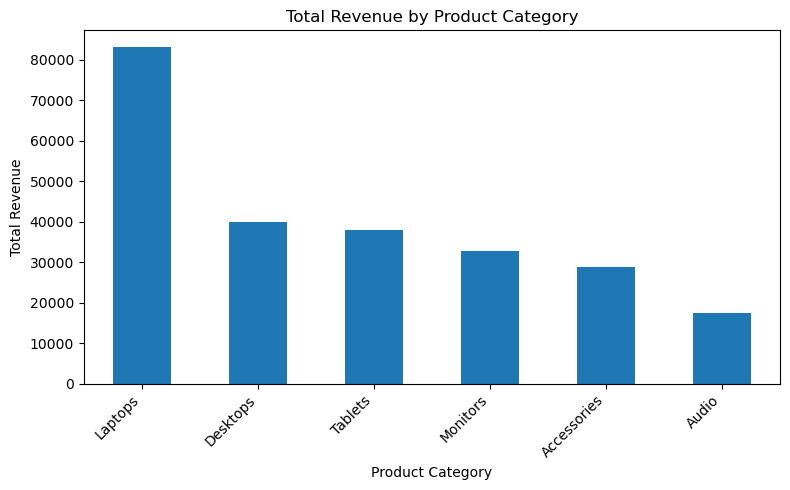

In [43]:
import matplotlib.pyplot as plt
revenue_by_category = df.groupby('category')['revenue'].sum().sort_values(ascending=False)

# Plot
ax = revenue_by_category.plot(kind='bar', figsize=(8, 5))

ax.set_title('Total Revenue by Product Category')
ax.set_xlabel('Product Category')
ax.set_ylabel('Total Revenue')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Task 8.2: Line Chart - Monthly Revenue Trend

Create a line chart showing total revenue by month.
- X-axis: Month (1-12)
- Y-axis: Total Revenue
- Add title and labels
- Use markers to show data points

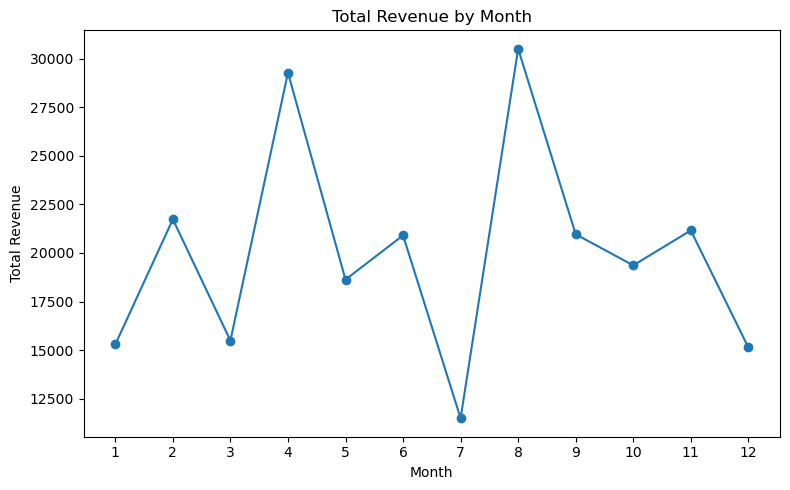

In [45]:
revenue_by_month = df.groupby('order_month')['revenue'].sum().sort_index()

# Plot
ax = revenue_by_month.plot(kind='line', marker='o', figsize=(8, 5))

ax.set_title('Total Revenue by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue')
ax.set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

## Task 8.3: Histogram - Revenue Distribution

Create a histogram showing the distribution of order revenues.
- Use 20 bins
- Add title: "Distribution of Order Revenue"
- Add axis labels

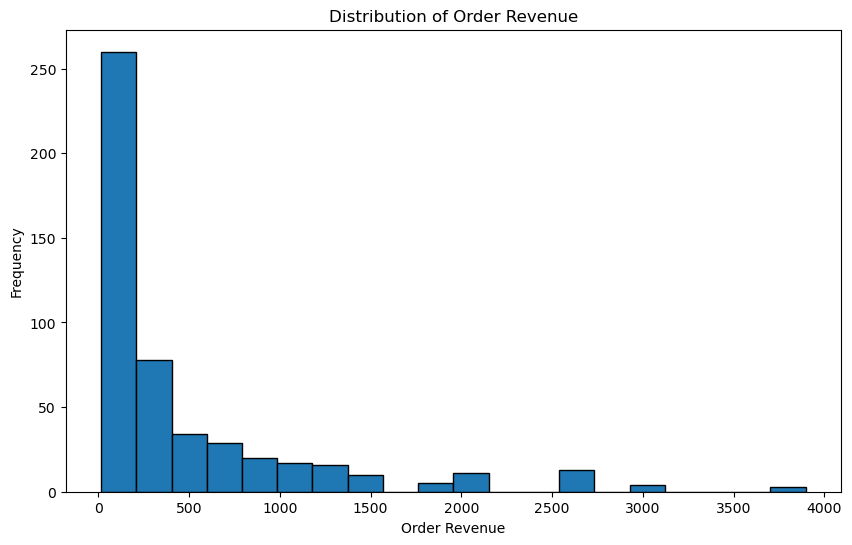

In [46]:
plt.figure(figsize=(10, 6))
plt.hist(df['revenue'], bins=20, edgecolor='black')

plt.title("Distribution of Order Revenue")
plt.xlabel("Order Revenue")
plt.ylabel("Frequency")

plt.show()

## Task 8.4: Box Plot - Revenue by Region

Create a box plot comparing revenue distribution across regions.
- Add title: "Order Revenue Distribution by Region"
- Add axis labels

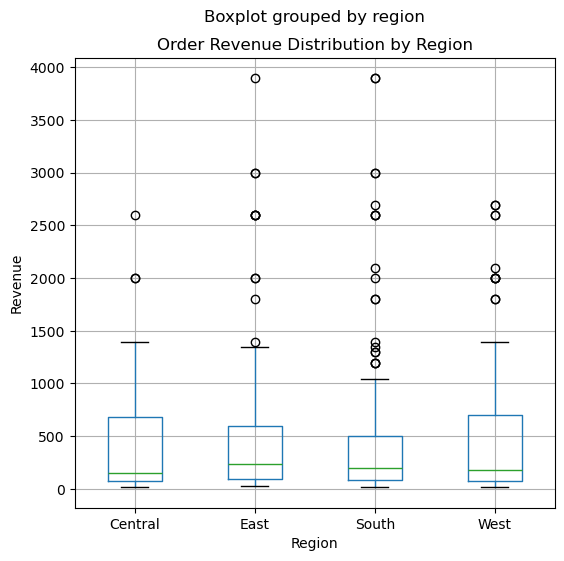

In [50]:
ax = df.boxplot(column='revenue', by='region', figsize=(6, 6))

plt.title("Order Revenue Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.show()

---

# Part 9: Business Insights (Putting It All Together)

## Task 9.1: Top Customers

Find the top 10 customers by total spending (sum of revenue).

Display: customer_id, full_name, city, membership, total_orders, total_revenue

Hint: You'll need to group by customer and aggregate.

In [68]:
(df.groupby(['customer_id', 'full_name', 'city', 'membership'])['revenue']
    .agg(total_orders='count', total_revenue='sum')
    .reset_index()
    .sort_values('total_revenue', ascending=False)
    .head(10)
)

,customer_id,full_name,city,membership,total_orders,total_revenue
107,111,David Brown,San Antonio,Basic,7,6056.0
23,25,Jennifer Gonzalez,Phoenix,Gold,4,5970.0
72,74,Thomas Davis,Philadelphia,Gold,5,5678.0
129,134,Thomas Garcia,Houston,Gold,5,5463.0
111,115,Charles Davis,Philadelphia,Gold,5,5412.0
2,3,Robert Johnson,Los Angeles,Gold,5,5391.0
51,53,John Garcia,Los Angeles,Basic,4,5310.0
74,76,Sarah Hernandez,New York,Gold,4,5003.0
54,56,Richard Smith,Philadelphia,Gold,5,4893.0
24,26,Joseph Davis,Phoenix,Premium,5,4834.0


## Task 9.2: Best-Selling Products

Find the top 5 products by:
1. Total quantity sold
2. Total revenue generated

Are they the same products? Why or why not?

In [81]:
df.columns

Index(['order_id', 'customer_id', 'product_id', 'quantity', 'order_date',
       'status', 'product_name', 'category', 'price', 'cost', 'first_name',
       'last_name', 'email', 'city', 'join_date', 'membership', 'region',
       'revenue', 'profit', 'order_month', 'order_quarter', 'order_day_name',
       'is_weekend', 'full_name', 'email_domain', 'revenue_category'],
      dtype='object')

In [85]:
df.groupby(['product_id','product_name'])['quantity'].sum().sort_values(ascending=False).head()

product_id  product_name       
123         Screen Protector       44.0
107         Mechanical Keyboard    43.0
122         Smartphone Case        42.0
119         Earbuds Sport          41.0
108         Wireless Keyboard      39.0
Name: quantity, dtype: float64

In [83]:
df.groupby(['product_id','product_name'])['revenue'].sum().sort_values(ascending=False).head()

product_id  product_name  
101         Laptop Pro 15"    44166.0
102         Laptop Air 13"    38961.0
121         Tablet 12"        25863.0
103         Desktop Tower     22475.0
104         Desktop Mini      17371.0
Name: revenue, dtype: float64

## Task 9.3: Weekend vs Weekday Sales

Compare weekend vs weekday orders:
1. Number of orders
2. Total revenue
3. Average order value

When do customers spend more per order?

In [86]:
df.groupby('is_weekend')['order_id'].count()

is_weekend
False    367
True     133
Name: order_id, dtype: int64

In [87]:
df.groupby('is_weekend')['revenue'].sum()

is_weekend
False    175752.0
True      64198.0
Name: revenue, dtype: float64

In [88]:
df.groupby('is_weekend')['revenue'].mean()

is_weekend
False    478.888283
True     482.691729
Name: revenue, dtype: float64

## Task 9.4: Product Profitability Analysis

Calculate for each product:
1. Total revenue
2. Total profit
3. Profit margin percentage = (profit / revenue) * 100

Which products have the highest profit margin? Are high-revenue products also high-margin?

In [102]:
revenue = df.groupby(['product_id','product_name'])['revenue'].sum().sort_values(ascending=False)
revenue.sort_values(ascending=False)

product_id  product_name       
101         Laptop Pro 15"         44166.0
102         Laptop Air 13"         38961.0
121         Tablet 12"             25863.0
103         Desktop Tower          22475.0
104         Desktop Mini           17371.0
110         Monitor 32"            16164.0
120         Tablet 10"             11976.0
111         Monitor 24"             8964.0
109         Monitor 27"             7678.0
107         Mechanical Keyboard     5547.0
118         Earbuds Wireless        5364.0
116         Headphones Pro          5083.0
113         Webcam 4K               4917.0
119         Earbuds Sport           4059.0
108         Wireless Keyboard       3471.0
125         Monitor Arm             3382.0
117         Headphones Basic        2923.0
112         Webcam HD               2346.0
106         Gaming Mouse            1896.0
124         Laptop Stand            1888.0
105         Wireless Mouse          1764.0
115         USB-C Adapter           1170.0
122         Smartphone

In [103]:
profit = df.groupby(['product_id','product_name'])['profit'].sum().sort_values(ascending=False)
profit.sort_values(ascending=False)

product_id  product_name       
101         Laptop Pro 15"         16966.0
102         Laptop Air 13"         13611.0
121         Tablet 12"             10323.0
103         Desktop Tower           8725.0
110         Monitor 32"             6444.0
104         Desktop Mini            6351.0
120         Tablet 10"              4776.0
111         Monitor 24"             3924.0
109         Monitor 27"             3278.0
107         Mechanical Keyboard     2967.0
118         Earbuds Wireless        2844.0
113         Webcam 4K               2607.0
116         Headphones Pro          2533.0
119         Earbuds Sport           2214.0
108         Wireless Keyboard       1911.0
125         Monitor Arm             1862.0
117         Headphones Basic        1628.0
112         Webcam HD               1326.0
124         Laptop Stand            1088.0
106         Gaming Mouse            1056.0
105         Wireless Mouse          1044.0
115         USB-C Adapter            630.0
122         Smartphone

In [98]:
profit_margin_percentage = (profit/revenue)*100
profit_margin_percentage.sort_values(ascending=False)

product_id  product_name       
123         Screen Protector       66.666667
122         Smartphone Case        60.000000
105         Wireless Mouse         59.183673
114         USB Hub                58.620690
124         Laptop Stand           57.627119
112         Webcam HD              56.521739
106         Gaming Mouse           55.696203
117         Headphones Basic       55.696203
125         Monitor Arm            55.056180
108         Wireless Keyboard      55.056180
119         Earbuds Sport          54.545455
115         USB-C Adapter          53.846154
107         Mechanical Keyboard    53.488372
118         Earbuds Wireless       53.020134
113         Webcam 4K              53.020134
116         Headphones Pro         49.832776
111         Monitor 24"            43.775100
109         Monitor 27"            42.693410
121         Tablet 12"             39.914163
120         Tablet 10"             39.879760
110         Monitor 32"            39.866370
103         Desktop Tow

---

# Part 10: Executive Summary

Based on your analysis, write a brief executive summary answering these questions:

1. **Overall Performance**: What is the total revenue and profit for TechMart in 2024?

2. **Top Product Category**: Which product category drives the most revenue?

3. **Customer Insights**: Which membership type is most valuable? Which region generates the most revenue?

4. **Seasonal Trends**: Are there any notable monthly or quarterly trends?

5. **Recommendations**: Based on your analysis, what would you recommend to TechMart's management?

In [108]:
df['revenue'].sum()

np.float64(239950.0)

In [109]:
df['profit'].sum()

np.float64(99654.0)

In [110]:
df.groupby(['category'])['revenue'].sum().sort_values(ascending=False)

category
Laptops        83127.0
Desktops       39846.0
Tablets        37839.0
Monitors       32806.0
Accessories    28903.0
Audio          17429.0
Name: revenue, dtype: float64

In [111]:
df.columns

Index(['order_id', 'customer_id', 'product_id', 'quantity', 'order_date',
       'status', 'product_name', 'category', 'price', 'cost', 'first_name',
       'last_name', 'email', 'city', 'join_date', 'membership', 'region',
       'revenue', 'profit', 'order_month', 'order_quarter', 'order_day_name',
       'is_weekend', 'full_name', 'email_domain', 'revenue_category'],
      dtype='object')

In [112]:
df.groupby('membership')['revenue'].sum().sort_values(ascending=False)

membership
Basic      120679.0
Gold        68956.0
Premium     50315.0
Name: revenue, dtype: float64

In [113]:
df.groupby('region')['revenue'].sum().sort_values(ascending=False)

region
South      90697.0
West       67171.0
East       57175.0
Central    24907.0
Name: revenue, dtype: float64

In [115]:
monthly_sales = df.groupby('order_month')['revenue'].agg(['count','sum'])
quarterly_sales = df.groupby('order_quarter')['revenue'].agg(['count','sum'])
monthly_sales.sort_values('sum',ascending=False)

,count,sum
order_month,,
8,47,30504.0
4,50,29277.0
2,49,21731.0
11,37,21159.0
9,45,20962.0
6,41,20906.0
10,43,19362.0
5,53,18630.0
3,21,15492.0


In [116]:
quarterly_sales.sort_values('sum',ascending=False)

,count,sum
order_quarter,,
2,144,68813.0
3,130,62962.0
4,125,55660.0
1,101,52515.0


## Your Executive Summary

Write your summary here (double-click to edit):

1. **Overall Performance**: 
   - Total Revenue: $239950.0
   - Total Profit: $99654.0

2. **Top Product Category**:
   - Laptops, revenue $83127.0
    
4. **Customer Insights**: 
    - Basic membership generates the most revenue: 120679.0
    - 2nd place Gold:$68956.0
    - South region generates the most revenue: 90697.0
    - 2nd place West:$67171.0
5. **Seasonal Trends**: 
    - August is the month with most revenue: 30504.0, Quarter 2 is the quarter with most revenue  ($68813.0) and order counts (144)
6. **Recommendations**: 
    - South region is the area with the most revenue, prioritize this region for new stores or promotional discounts

---

# Congratulations!

You have completed the TechMart E-Commerce Analysis case study!

## Skills Demonstrated

- [x] Loading and exploring data (head, tail, sample, info, describe)
- [x] Handling missing values and duplicates
- [x] Merging multiple DataFrames
- [x] Creating calculated columns
- [x] DateTime feature engineering
- [x] String operations
- [x] Using apply() with custom functions
- [x] Filtering with single and multiple conditions
- [x] Sorting data
- [x] GroupBy aggregations
- [x] Pivot tables
- [x] Data visualization (bar, line, histogram, box plots)
- [x] Business analysis and insights

## Next Steps

1. Try the `Pandas_Project/` folder for more practice
2. Apply these skills to your own datasets
3. Move on to Module 02: Data Exploration and Preparation